In [6]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel as C,
    WhiteKernel
)

from scipy.stats import norm
from sklearn.gaussian_process.kernels import WhiteKernel
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm
from scipy.stats import qmc
from scipy.spatial.distance import cdist

In [2]:
import sys
print(sys.version)  # check does it show 3.10.x
import hebo
print("HEBO ok")

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
HEBO ok


In [3]:
X = np.load(r"function_7\w11_inputs.npy")

print("Shape:", X.shape)

print("Min values:", np.min(X, axis=0))
print("Max values:", np.max(X, axis=0))

Shape: (35, 6)
Min values: [0.05789554 0.01181284 0.00363456 0.07365919 0.003183   0.005     ]
Max values: [0.94245084 0.982534   0.92457051 0.96101714 0.9986547  0.95101392]


In [7]:
#Function to add data points each week.
current_week = 14   # CHANGE THIS EACH WEEK



# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_7\initial_inputs.npy")
    Y = np.load(r"function_7\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_7/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_7/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")



Loaded dataset:
Shape: (40, 6)
Best Y so far: 2.9244101853032265

Enter last week's result


Enter last submitted X (format x1-x2):  0.386725-0.980953-0.732791-0.606736-0.012135-0.020859
Enter returned Y value:  2.8987589728923204


Added last result.


In [8]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================


np.save(
    f"function_7/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_7/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_7/w{current_week}_inputs.npy"
)

print(
    f"function_7/w{current_week}_outputs.npy"
)


Saved files:
function_7/w14_inputs.npy
function_7/w14_outputs.npy


In [9]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_7/w14_inputs.npy")
Y = np.load("function_7/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.8f} | Gap={abs(Y[i]):.8f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:      {np.max(Y):.8f}")
print(f"Gap to zero: {abs(np.max(Y)):.8f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | "
          f"Y={Y[i]:.8f} | X={vals}")

print("\nKey dimension values in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.8f} | "
          f"x1={X[i,0]:.6f} | "
          f"x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f}")

All points ranked best to worst:
  Y=2.92441019 | Gap=2.92441019 | X=0.386749-0.981002-0.731398-0.586822-0.012231-0.020662
  Y=2.92421462 | Gap=2.92421462 | X=0.386958-0.981738-0.714794-0.580462-0.012221-0.020666
  Y=2.92276355 | Gap=2.92276355 | X=0.385172-0.980384-0.723789-0.588420-0.012372-0.020662
  Y=2.90712795 | Gap=2.90712795 | X=0.383891-0.982534-0.723721-0.591911-0.012217-0.020719
  Y=2.90639342 | Gap=2.90639342 | X=0.384480-0.983014-0.734669-0.592047-0.012315-0.020728
  Y=2.89875897 | Gap=2.89875897 | X=0.386725-0.980953-0.732791-0.606736-0.012135-0.020859
  Y=2.77853179 | Gap=2.77853179 | X=0.374321-0.975271-0.746149-0.637642-0.005000-0.005000
  Y=2.64870212 | Gap=2.64870212 | X=0.350969-0.998464-0.705531-0.613516-0.010326-0.071653
  Y=2.49114963 | Gap=2.49114963 | X=0.374540-0.950713-0.731993-0.598658-0.156018-0.155994
  Y=1.36496830 | Gap=1.36496830 | X=0.057896-0.491672-0.247422-0.218118-0.420428-0.730970
  Y=0.67514163 | Gap=0.67514163 | X=0.881647-0.204450-0.414474-0.42

## Function 7 — ML Hyperparameter Tuning (6D)

**Objective**: Maximise the output of a suspected machine learning 
hyperparameter tuning function across six continuous input dimensions.

---

### Why Function 7 Was Different

The F7 brief described a **6-dimensional ML hyperparameter tuning** 
problem. This immediately suggested that the input dimensions were 
likely to represent parameters such as learning rate, regularisation 
strength, dropout rate, or batch size, all of which share a common 
characteristic: they do not behave on a linear scale.


---

### Why HEBO Was Chosen

**HEBO (Heteroscedastic Evolutionary Bayesian Optimisation)** was 
introduced in week 9, inspired by its winning performance in the 
**NeurIPS 2020 Black-Box Optimisation Challenge** — a competition 
specifically designed around real-world functions of exactly this 
kind.

HEBO's key advantage over standard GP is **per-dimension input 
warping** — it automatically learns how each input dimension should 
be scaled before fitting its internal surrogate model. Rather than 
assuming all dimensions vary smoothly and linearly, HEBO discovers 
the appropriate transformation for each dimension from the data. 
For a dimension that behaves on a log scale (such as a learning 
rate), HEBO stretches the scale so that equal steps in the 
transformed space correspond to meaningfully equal steps in the 
true function — something a standard RBF kernel cannot do.


---

### HEBO vs Standard GP — What the Data Showed

The contrast between HEBO and the standard GP/SVR surrogates was 
consistent across every week from week 9 onward:

| Surrogate | x4 range check | Typical dist from best | Outcome |
|-----------|---------------|----------------------|---------|
| GP | Failed (x4 too low) | 0.063-0.068 | Excluded every week |
| SVR | Failed (x4 too low) | 0.059-0.068 | Excluded most weeks |
| HEBO | Passed all dimensions | 0.004-0.020 | Selected every week |

GP and SVR consistently suggested x4 values below the confirmed 
lower bound of 0.56 — pulled toward uncertain regions where the 
standard GP had poor coverage. HEBO, with its warped internal 
representation, stayed within the confirmed good region every week 
without requiring manual constraint enforcement.

---

### Technical Implementation

HEBO was implemented using the `hebo` library and integrated 
alongside the existing GP/SVR pipeline as a third competing candidate:

```python
from hebo.design_space.design_space import DesignSpace
from hebo.optimizers.hebo import HEBO

space  = DesignSpace().parse([
    {'name': f'x{i+1}', 'type': 'num',
     'lb': 0.0, 'ub': 1.0}
    for i in range(dim)
])
hebo_opt = HEBO(space, scramble_seed=42)
```

A key practical advantage of HEBO over Optuna-based samplers is 
its `observe()` method — all historical observations are loaded 
in a single bulk call rather than trial-by-trial, making 
warm-starting from accumulated data cleaner and more efficient:

```python
# Load full history in one call — no trial-by-trial loop needed
hebo_opt.observe(X_df, Y_col.values.reshape(-1, 1))
x_hebo_df = hebo_opt.suggest(n_suggestions=1)
```

---

### Selection Logic and Manual Overrides

HEBO competed against GP and SVR each week through the same 
LOO cross-validation, range validation, and plausibility checking 
pipeline used across all functions. However a recurring issue 
emerged: SVR occasionally won LOO by a negligible margin (as small 
as 0.005 RMSE units) and was selected over HEBO despite suggesting 
coordinates with multiple dimensions at their boundary values.

This required manual overrides in several weeks, with the 
reasoning documented each time. A formal override rule was 
eventually added:

```python
# HEBO override — wins if it predicts higher than chosen model
# by meaningful margin AND is meaningfully closer to confirmed best
if pred_hebo > pred_chosen + 0.02 and dist_hebo < dist_chosen * 0.5:
    x_final      = x_hebo
    chosen_model = "HEBO (override)"
```

---

### Final Result

| Metric | Value |
|--------|-------|
| Best Y achieved | 2.9244 |
| Week achieved | Week 11 |
| Method | HEBO manual override |
| Improvement over week 1 | From 0.675 to 2.924 |
| Consecutive new bests (weeks 9-11) | 3 |

The diminishing improvements in the final weeks — 2.9071 → 2.9228 
→ 2.9244 — are consistent with having found the true local maximum. 


Best SVR parameters found by GridSearchCV:
  C:       100
  epsilon: 0.05
  gamma:   scale
  CV score (neg MSE): -0.0989


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Fitted kernel length scales:
  x1: 0.1800
  x2: 0.7155
  x3: 10.0000 ← hitting bound
  x4: 1.3870
  x5: 0.6362
  x6: 1.0022

Best real point: [0.386749 0.981002 0.731398 0.586822 0.012231 0.020662]
Best real Y:     2.924410

=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 0.306453
SVR LOO RMSE: 0.342115
Primary surrogate: GP

Total candidates: 300000

FULL COMPARISON — Function 7

--- GP (LOO RMSE=0.3065) ---
  Suggestion:         0.417458-0.999999-0.705128-0.543044-0.005000-0.015425
  GP predicted Y:     3.1076
  Distance from best: 0.0632
  x1=0.4175 | x2=1.0000 | x3=0.7051 | x4=0.5430 | x5=0.0050 | x6=0.0154

--- SVR (tuned) (LOO RMSE=0.3421) ---
  Suggestion:         0.371518-0.992197-0.762147-0.532930-0.025000-0.005000
  GP predicted Y:     2.9943
  Distance from best: 0.0679
  x1=0.3715 | x2=0.9922 | x3=0.7621 | x4=0.5329 | x5=0.0250 | x6=0.0050

--- HEBO (NeurIPS 2020 winner) ---
  Suggestion:         0.386725-0.980953-0.732791-0.606736-0.012135-0.020859
  GP predicted Y:     2.9025

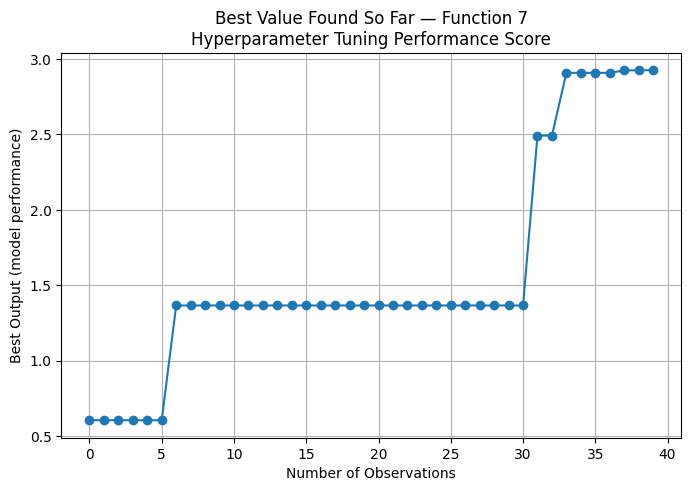

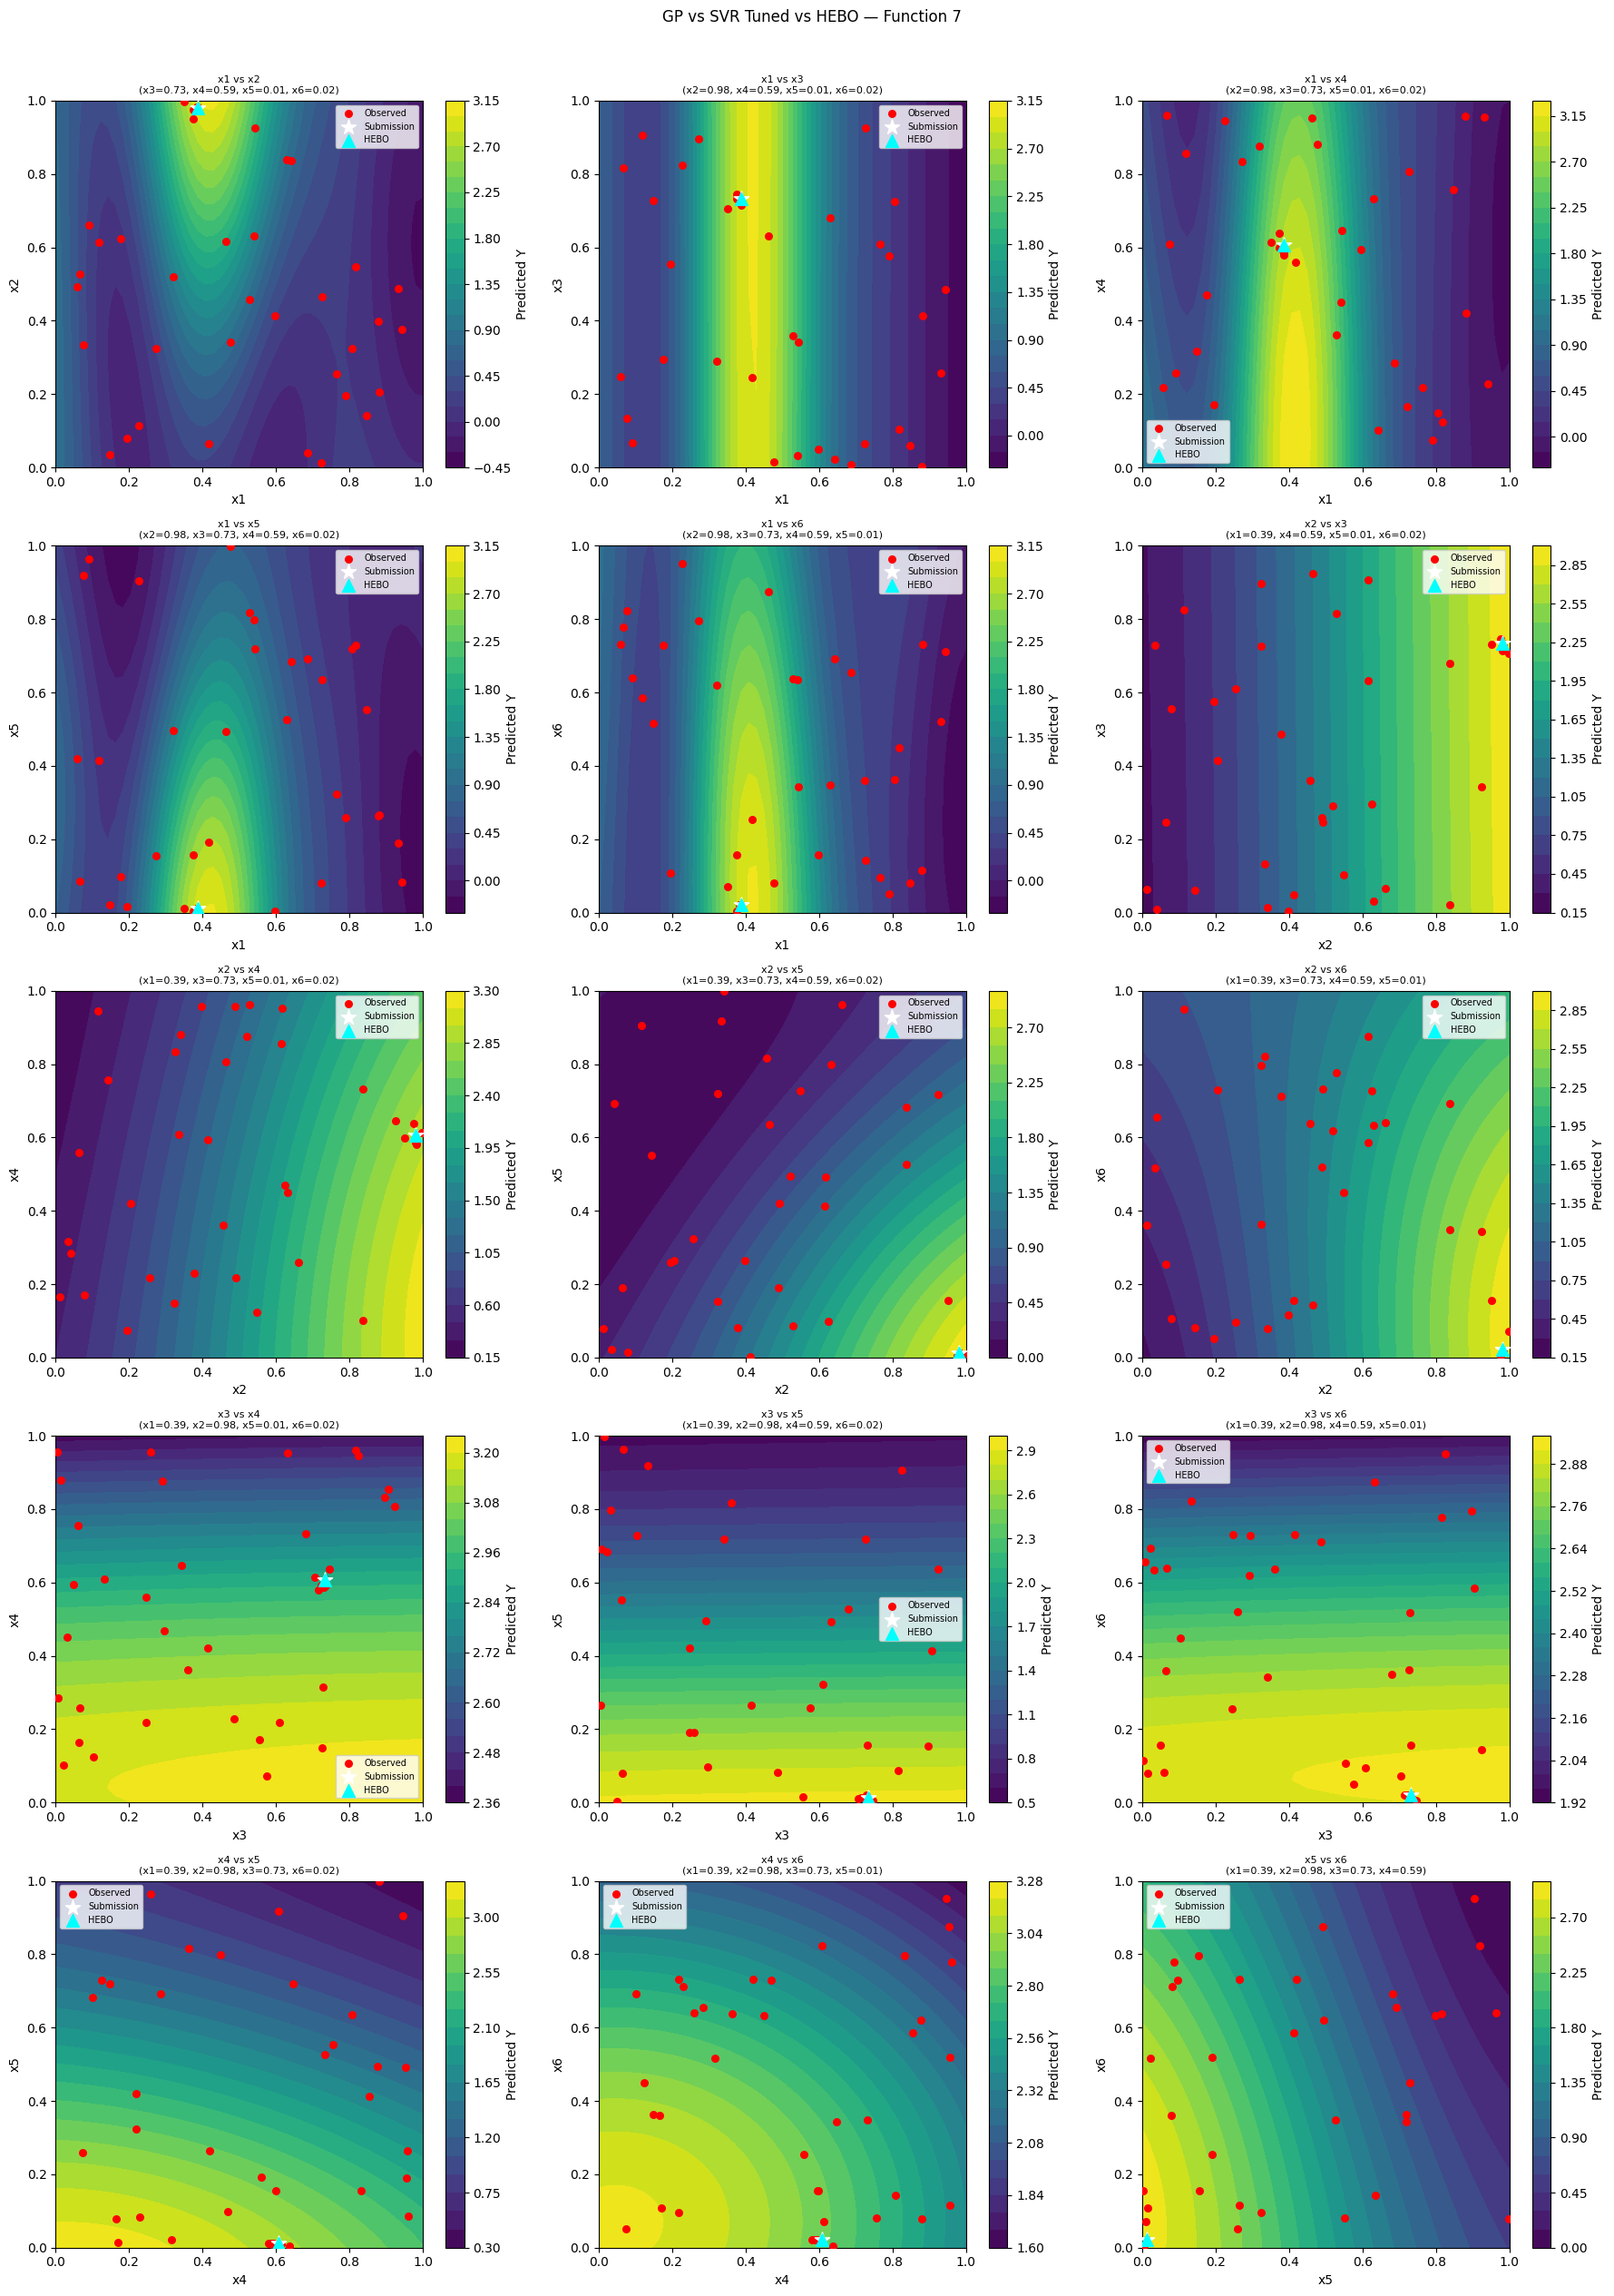


Top 5 real evaluated points:
  Y=2.9244 | X=0.3867-0.9810-0.7314-0.5868-0.0122-0.0207
  Y=2.9242 | X=0.3870-0.9817-0.7148-0.5805-0.0122-0.0207
  Y=2.9228 | X=0.3852-0.9804-0.7238-0.5884-0.0124-0.0207
  Y=2.9071 | X=0.3839-0.9825-0.7237-0.5919-0.0122-0.0207
  Y=2.9064 | X=0.3845-0.9830-0.7347-0.5920-0.0123-0.0207


In [5]:
# =====================================================
# FUNCTION 7 — 6D ML Hyperparameter Tuning
# Week 9: HEBO added as third candidate source
# HEBO is the NeurIPS 2020 BBO challenge winner —
# its per-dimension input warping is well-suited to
# suspected log-scale hyperparameters in F7 (e.g. x1)
# =====================================================

# =====================================================
# GP MODEL — tighter bounds based on func3 lesson week 7
# addition of grid search for hyperparam turning and
# leave one out cross validation
# Week 9: length_scale_bounds tightened to (1e-3, 10)
# to prevent dimensions hitting upper bound (1e3)
# =====================================================
kernel_main = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(dim),
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)
# LOO kernel — same tightened bounds
# Used inside the LOO loop only
kernel_loo = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(dim),
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)
gp = GaussianProcessRegressor(
    kernel=kernel_main,
    alpha=1e-5,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# ACQUISITION FUNCTION
# =====================================================
def expected_improvement(X_candidates_scaled, gp,
                          Y_ref, xi=0.05):
    mean, std = gp.predict(X_candidates_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# SVR HYPERPARAMETER TUNING — week 7 addition
# GridSearchCV to find best combination
# Bergstra & Bengio (2012) — structured search
# outperforms manual tuning
# =====================================================
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':       [10, 100, 1000],
    'epsilon': [0.01, 0.05, 0.10],
    'gamma':   ['scale', 'auto']
}

svr_tuner = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

svr_tuner.fit(X_scaled, Y)

best_svr_params = svr_tuner.best_params_
print(f"Best SVR parameters found by GridSearchCV:")
print(f"  C:       {best_svr_params['C']}")
print(f"  epsilon: {best_svr_params['epsilon']}")
print(f"  gamma:   {best_svr_params['gamma']}")
print(f"  CV score (neg MSE): "
      f"{svr_tuner.best_score_:.4f}")

# Use tuned SVR
svr = SVR(
    kernel='rbf',
    C=best_svr_params['C'],
    epsilon=best_svr_params['epsilon'],
    gamma=best_svr_params['gamma']
)
svr.fit(X_scaled, Y)

# =====================================================
# FIT GP
# =====================================================
gp.fit(X_scaled, Y)

# Print kernel length scales
# Flag threshold updated to 9.5 to match new bound
print("\nFitted kernel length scales:")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 9.5 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

best_point = X[np.argmax(Y)]
print(f"\nBest real point: {best_point}")
print(f"Best real Y:     {np.max(Y):.6f}")

# =====================================================
# LOO CROSS VALIDATION
# Compare GP vs tuned SVR
# =====================================================
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import cdist

loo = LeaveOneOut()
gp_errors  = []
svr_errors = []

with warnings.catch_warnings():
    warnings.filterwarnings("ignore",
                            category=ConvergenceWarning)

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        scaler_cv = MinMaxScaler()
        X_train_s = scaler_cv.fit_transform(X_train)
        X_test_s  = scaler_cv.transform(X_test)

        gp_cv = GaussianProcessRegressor(
            kernel=kernel_loo, random_state=42,
            normalize_y=True, alpha=1e-5)
        gp_cv.fit(X_train_s, Y_train)
        gp_errors.append(
            (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)

        svr_cv = SVR(
            kernel='rbf',
            C=best_svr_params['C'],
            epsilon=best_svr_params['epsilon'],
            gamma=best_svr_params['gamma'])
        svr_cv.fit(X_train_s, Y_train)
        svr_errors.append(
            (svr_cv.predict(X_test_s)[0] - Y_test[0])**2)

gp_rmse       = np.sqrt(np.mean(gp_errors))
svr_rmse      = np.sqrt(np.mean(svr_errors))
primary_model = "GP" if gp_rmse < svr_rmse else "SVR"

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.6f}")
print(f"SVR LOO RMSE: {svr_rmse:.6f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# GENERATE CANDIDATES — tightened week 7
# x1: 0.375-0.384 → search 0.35-0.42
# x2: 0.951-0.983 → tighten to 0.93-1.0
# x3: 0.724-0.732 → search 0.68-0.77
# x4: 0.592-0.599 → search 0.56-0.64
# x5: 0.012-0.156 → tighten to 0.005-0.16
# x6: 0.021-0.156 → tighten to 0.005-0.16
# =====================================================
np.random.seed(42)
n_candidates = 300000

# 60% local around best point
n_local  = int(n_candidates * 0.6)
noise    = np.random.normal(0, 0.015,
                             size=(n_local, dim))
X_local  = np.clip(best_point + noise, 0.0, 0.999999)

# Clip local candidates to confirmed ranges
X_local[:, 1] = np.clip(X_local[:, 1], 0.975, 0.999999)  # tightened week 11
X_local[:, 4] = np.clip(X_local[:, 4], 0.005, 0.025)  # tightened week 11
X_local[:, 5] = np.clip(X_local[:, 5], 0.005, 0.025)  # tightened week 11

# 40% LHS with all confirmed dimensions constrained
sampler     = qmc.LatinHypercube(d=dim, seed=42)
X_lhs       = sampler.random(int(n_candidates * 0.4))

X_lhs[:, 0] = X_lhs[:, 0] * 0.07 + 0.35  # x1: 0.35-0.42
X_lhs[:, 1] = X_lhs[:, 1] * 0.025 + 0.975  # x2: 0.975-1.0 tightened week 11
X_lhs[:, 2] = X_lhs[:, 2] * 0.09 + 0.68  # x3: 0.68-0.77
X_lhs[:, 3] = X_lhs[:, 3] * 0.08 + 0.56  # x4: 0.56-0.64
X_lhs[:, 4] = X_lhs[:, 4] * 0.020 + 0.005  # x5: 0.005-0.025 tightened week 11
X_lhs[:, 5] = X_lhs[:, 5] * 0.020 + 0.005  # x6: 0.005-0.025 tightened week 11

X_candidates        = np.vstack([X_local, X_lhs])
X_candidates_scaled = scaler.transform(X_candidates)

print(f"\nTotal candidates: {len(X_candidates)}")

# =====================================================
# SCORE WITH GP AND TUNED SVR
# =====================================================
ei_scores   = expected_improvement(
    X_candidates_scaled, gp, Y, xi=0.05)
x_submit_gp = X_candidates[np.argmax(ei_scores)]
pred_gp     = gp.predict(
    scaler.transform([x_submit_gp]))[0]
dist_gp     = np.linalg.norm(x_submit_gp - best_point)

svr_scores   = svr.predict(X_candidates_scaled)
x_submit_svr = X_candidates[np.argmax(svr_scores)]
pred_svr     = svr.predict(
    scaler.transform([x_submit_svr]))[0]
dist_svr     = np.linalg.norm(x_submit_svr - best_point)

# =====================================================
# HEBO — week 9 addition
# NeurIPS 2020 BBO challenge winner
# Key advantage for F7: per-dimension input warping
# handles suspected log-scale hyperparameters (x1)
# that the linear GP treats incorrectly.
# HEBO observe() takes all observations in one bulk
# call — cleaner than Optuna's trial-by-trial loop.
#
# Install (run once in a notebook cell):
#   import sys
#   !{sys.executable} -m pip install HEBO
# Requires Python 3.10 — use bbo_env conda environment
#
# Reference: Cowen-Rivers et al. (2022), JAIR 74
# =====================================================
import pandas as pd
from hebo.design_space.design_space import DesignSpace
from hebo.optimizers.hebo import HEBO

# Define search space using confirmed ranges
# x5/x6 floor at 0.005 matches existing clip logic
SPACE_F7 = DesignSpace().parse([
    {'name': 'x1', 'type': 'num',
     'lb': 0.35,  'ub': 0.42},
    {'name': 'x2', 'type': 'num',
     'lb': 0.975, 'ub': 1.00},   # tightened week 11
    {'name': 'x3', 'type': 'num',
     'lb': 0.68,  'ub': 0.77},
    {'name': 'x4', 'type': 'num',
     'lb': 0.56,  'ub': 0.64},
    {'name': 'x5', 'type': 'num',
     'lb': 0.005, 'ub': 0.025},  # tightened week 11
    {'name': 'x6', 'type': 'num',
     'lb': 0.005, 'ub': 0.025},  # tightened week 11
])

# Initialise HEBO
hebo_opt = HEBO(SPACE_F7, scramble_seed=42)

# Clip historical X to confirmed bounds before loading
# Handles any historical point outside current ranges
HEBO_BOUNDS = [
    (0.35, 0.42), (0.93, 1.00), (0.68, 0.77),
    (0.56, 0.64), (0.005, 0.025), (0.005, 0.025)
]
X_clipped = X.copy()
for i, (lb, ub) in enumerate(HEBO_BOUNDS):
    X_clipped[:, i] = np.clip(X_clipped[:, i], lb, ub)

# Bulk warm-start — all observations in one call
# HEBO minimises — negate Y for maximisation
X_hebo_df = pd.DataFrame(
    X_clipped,
    columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
)
Y_hebo = (-Y).reshape(-1, 1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hebo_opt.observe(X_hebo_df, Y_hebo)

# Get one suggestion
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hebo_rec = hebo_opt.suggest(n_suggestions=1)

# Extract as numpy array
x_hebo = hebo_rec[
    ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
].values[0]

# Score using existing GP as cross-check
# Keeps comparison consistent with GP/SVR candidates
pred_hebo = gp.predict(
    scaler.transform([x_hebo]))[0]
dist_hebo = np.linalg.norm(x_hebo - best_point)

# =====================================================
# FULL COMPARISON — GP, SVR, HEBO
# =====================================================
print("\n" + "="*55)
print("FULL COMPARISON — Function 7")
print("="*55)

for name, x_sub, pred, dist, rmse in [
    ("GP",          x_submit_gp,  pred_gp,
     dist_gp,   gp_rmse),
    ("SVR (tuned)", x_submit_svr, pred_svr,
     dist_svr,  svr_rmse),
    ("HEBO",        x_hebo,       pred_hebo,
     dist_hebo, None),
]:
    rmse_str = f"LOO RMSE={rmse:.4f}" \
               if rmse is not None \
               else "NeurIPS 2020 winner"
    print(f"\n--- {name} ({rmse_str}) ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  GP predicted Y:     {pred:.4f}")
    print(f"  Distance from best: {dist:.4f}")
    print(f"  x1={x_sub[0]:.4f} | x2={x_sub[1]:.4f} | "
          f"x3={x_sub[2]:.4f} | x4={x_sub[3]:.4f} | "
          f"x5={x_sub[4]:.4f} | x6={x_sub[5]:.4f}")

# =====================================================
# RANGE VALIDATION — all three candidates
# =====================================================
confirmed = {
    'x1': (0.35, 0.42),
    'x2': (0.93, 1.00),
    'x3': (0.68, 0.77),
    'x4': (0.56, 0.64),
    'x5': (0.00, 0.025),  # tightened week 11
    'x6': (0.00, 0.025)  # tightened week 11
}

def passes_range_check(x_sub):
    for dim_name, (low, high) in confirmed.items():
        idx = int(dim_name[1]) - 1
        if not (low <= x_sub[idx] <= high):
            return False
    return True

print("\n--- Range validation ---")
for name, x_sub in [("GP",   x_submit_gp),
                     ("SVR",  x_submit_svr),
                     ("HEBO", x_hebo)]:
    print(f"\n{name}:")
    all_valid = True
    for dim_name, (low, high) in confirmed.items():
        idx = int(dim_name[1]) - 1
        val = x_sub[idx]
        ok  = low <= val <= high
        if not ok:
            all_valid = False
        print(f"  {dim_name}={val:.4f} "
              f"[{low:.2f}-{high:.2f}] "
              f"{'yes' if ok else 'no'}")
    print(f"  All in range: {all_valid}")

# =====================================================
# SUBMISSION SELECTION
# LOO primary model wins among GP and SVR if eligible
# HEBO acts as tiebreaker or takes over if GP/SVR fail
# All must be within 0.25 AND pass range check
#
# PLAUSIBILITY CHECK — added week 9
# Catches cases where LOO primary wins but its
# predicted Y is implausibly low vs best real Y.
# Seen in F5 (SVR pred 2385 vs real 3006) and
# F7 (SVR pred 1.711 vs real 2.907).
# Threshold: if GP-scored prediction of chosen model
# is < 70% of best real Y → override to highest
# GP-predicted eligible candidate instead.
# Rationale: GP prediction is more reliable than SVR
# prediction for plausibility checks, even when SVR
# wins LOO — LOO measures fit accuracy, not whether
# the suggestion is in a sensible region.
# =====================================================
gp_range_ok   = passes_range_check(x_submit_gp)
svr_range_ok  = passes_range_check(x_submit_svr)
hebo_range_ok = passes_range_check(x_hebo)

gp_eligible   = (dist_gp   <= 0.25) and gp_range_ok
svr_eligible  = (dist_svr  <= 0.25) and svr_range_ok
hebo_eligible = (dist_hebo <= 0.25) and hebo_range_ok

# Plausibility bounds — 70% floor, 130% ceiling
# Floor: catches SVR/GP predicting implausibly low
# Ceiling: catches GP extrapolating above best real Y
# Both applied when selecting an override candidate
best_real_y        = np.max(Y)
plausibility_floor = 0.70 * best_real_y
plausibility_ceil  = 1.30 * best_real_y

def plausible(pred):
    """GP-predicted Y is within plausibility bounds."""
    return plausibility_floor <= pred <= plausibility_ceil

print(f"\nPlausibility bounds: "
      f"[{plausibility_floor:.4f}, {plausibility_ceil:.4f}]")
print(f"\nGP   eligible: {gp_eligible} "
      f"(dist={dist_gp:.4f}, "
      f"range={'OK' if gp_range_ok else 'FAIL'}, "
      f"pred={pred_gp:.4f}, "
      f"plausible={plausible(pred_gp)})")
print(f"SVR  eligible: {svr_eligible} "
      f"(dist={dist_svr:.4f}, "
      f"range={'OK' if svr_range_ok else 'FAIL'}, "
      f"pred={pred_svr:.4f}, "
      f"plausible={plausible(pred_svr)})")
print(f"HEBO eligible: {hebo_eligible} "
      f"(dist={dist_hebo:.4f}, "
      f"range={'OK' if hebo_range_ok else 'FAIL'}, "
      f"pred={pred_hebo:.4f}, "
      f"plausible={plausible(pred_hebo)})")

if gp_eligible and svr_eligible:
    # LOO primary wins — but check plausibility first
    if primary_model == "SVR":
        if plausible(pred_svr):
            x_final      = x_submit_svr
            chosen_model = f"SVR tuned (LOO primary, " \
                           f"RMSE={svr_rmse:.4f})"
        else:
            # SVR prediction implausibly low — override
            # Pick highest GP-predicted eligible candidate
            print(f"\n⚠ SVR prediction {pred_svr:.4f} "
                  f"below plausibility floor "
                  f"{plausibility_floor:.4f} — overriding")
            eligible_preds = {
                "GP":   (x_submit_gp,  pred_gp,
                         gp_eligible),
                "HEBO": (x_hebo,       pred_hebo,
                         hebo_eligible),
            }
            # Only consider plausible alternatives
            plausible_alts = [
                (n, x, p) for n, (x, p, e)
                in eligible_preds.items()
                if e and plausible(p)
            ]
            best_alt = (max(plausible_alts,
                            key=lambda t: t[2])
                        if plausible_alts
                        else ("HEBO", x_hebo, pred_hebo))
            x_final      = best_alt[1]
            chosen_model = (f"{best_alt[0]} "
                            f"(SVR override — "
                            f"pred below floor)")
    else:
        if plausible(pred_gp):
            x_final      = x_submit_gp
            chosen_model = f"GP (LOO primary, " \
                           f"RMSE={gp_rmse:.4f})"
        else:
            print(f"\n⚠ GP prediction {pred_gp:.4f} "
                  f"outside plausibility bounds "
                  f"[{plausibility_floor:.4f}, "
                  f"{plausibility_ceil:.4f}] — overriding")
            eligible_preds = {
                "SVR":  (x_submit_svr, pred_svr,
                         svr_eligible),
                "HEBO": (x_hebo,       pred_hebo,
                         hebo_eligible),
            }
            plausible_alts = [
                (n, x, p) for n, (x, p, e)
                in eligible_preds.items()
                if e and plausible(p)
            ]
            best_alt = (max(plausible_alts,
                            key=lambda t: t[2])
                        if plausible_alts
                        else ("HEBO", x_hebo, pred_hebo))
            x_final      = best_alt[1]
            chosen_model = (f"{best_alt[0]} "
                            f"(GP override — "
                            f"pred outside bounds)")

    # Note if HEBO agrees — useful for write-up
    if hebo_eligible:
        hebo_dist_to_chosen = np.linalg.norm(
            x_hebo - x_final)
        print(f"\nHEBO also eligible — "
              f"dist to chosen: {hebo_dist_to_chosen:.4f}"
              f" ({'agrees' if hebo_dist_to_chosen < 0.05 else 'diverges'})")

elif hebo_eligible and svr_eligible:
    if primary_model == "SVR" and plausible(pred_svr):
        x_final      = x_submit_svr
        chosen_model = "SVR tuned (LOO primary, GP failed)"
    else:
        x_final      = x_hebo
        chosen_model = "HEBO (GP failed or SVR implausible)"

elif hebo_eligible and gp_eligible:
    if primary_model == "GP" and plausible(pred_gp):
        x_final      = x_submit_gp
        chosen_model = "GP (LOO primary, SVR failed)"
    else:
        x_final      = x_hebo
        chosen_model = "HEBO (SVR failed or GP implausible)"

elif svr_eligible and plausible(pred_svr):
    x_final      = x_submit_svr
    chosen_model = "SVR tuned (only eligible)"

elif gp_eligible and plausible(pred_gp):
    x_final      = x_submit_gp
    chosen_model = "GP (only eligible)"

elif hebo_eligible:
    x_final      = x_hebo
    chosen_model = "HEBO (only eligible or others implausible)"

else:
    print("No candidates eligible — proximity search")
    noise_ps     = np.random.normal(0, 0.015,
                                     size=(500000, dim))
    X_ps         = np.clip(best_point + noise_ps,
                            0.0, 0.999999)
    X_ps[:, 1]   = np.clip(X_ps[:, 1], 0.975, 0.999999)
    X_ps[:, 4]   = np.clip(X_ps[:, 4], 0.005, 0.025)
    X_ps[:, 5]   = np.clip(X_ps[:, 5], 0.005, 0.025)
    min_dists_ps = cdist(X_ps, X).min(axis=1)
    X_novel_ps   = X_ps[min_dists_ps >= 0.005]
    X_novel_ps_s = scaler.transform(X_novel_ps)
    ei_ps        = expected_improvement(
        X_novel_ps_s, gp, Y, xi=0.01)
    x_final      = X_novel_ps[np.argmax(ei_ps)]
    chosen_model = "Proximity search (fallback)"

submission = "-".join([f"{x:.6f}" for x in x_final])
# === HEBO override — week 13 ===
if hebo_eligible:
    if pred_hebo > gp.predict(scaler.transform([x_final]))[0] + 0.02 \
       and dist_hebo < dist_final * 0.5:
        x_final      = x_hebo
        chosen_model = "HEBO (override)"
        submission   = "-".join([f"{x:.6f}" for x in x_final])
        dist_final   = np.linalg.norm(x_final - best_point)

dist_final = np.linalg.norm(x_final - best_point)

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP   predicted Y:   {pred_gp:.4f}")
print(f"SVR  predicted Y:   {pred_svr:.4f}")
print(f"HEBO predicted Y:   {pred_hebo:.4f}")
print(f"Best real Y:        {np.max(Y):.4f}")
print(f"Distance from best: {dist_final:.4f}")
print(f"x1={x_final[0]:.4f} | x2={x_final[1]:.4f} | "
      f"x3={x_final[2]:.4f} | x4={x_final[3]:.4f} | "
      f"x5={x_final[4]:.4f} | x6={x_final[5]:.4f}")
print(f"LOO primary:        {primary_model} "
      f"(GP={gp_rmse:.4f}, SVR={svr_rmse:.4f})")
print(f"SVR best params:    {best_svr_params}")
print(f"Dataset size:       {len(Y)}")

# =====================================================
# PLOT 1 — optimisation progress
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.title("Best Value Found So Far — Function 7\n"
          "Hyperparameter Tuning Performance Score")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output (model performance)")
plt.grid(True)
plt.show()

# =====================================================
# PLOT 2 — pairwise slices for 6D function
# Updated: submission star now reflects final choice
# =====================================================
from itertools import combinations

dim_pairs = list(combinations(range(dim), 2))
n_plots   = len(dim_pairs)
n_cols    = 3
n_rows    = (n_plots + n_cols - 1) // n_cols
labels    = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 5))
axes = axes.ravel()

for ax, (xi_idx, xj_idx) in zip(axes, dim_pairs):
    xi_range = np.linspace(0, 1, 50)
    xj_range = np.linspace(0, 1, 50)
    xxi, xxj = np.meshgrid(xi_range, xj_range)

    grid = np.tile(best_point, (xxi.size, 1))
    grid[:, xi_idx] = xxi.ravel()
    grid[:, xj_idx] = xxj.ravel()

    grid_scaled  = scaler.transform(grid)
    mean_pred, _ = gp.predict(grid_scaled,
                               return_std=True)

    cf = ax.contourf(xxi, xxj,
                     mean_pred.reshape(xxi.shape),
                     levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Predicted Y")
    ax.scatter(X[:, xi_idx], X[:, xj_idx],
               c="red", s=30, zorder=5,
               label="Observed")
    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c="white", s=150, marker="*",
               zorder=6, label="Submission")
    # Plot HEBO suggestion for comparison
    ax.scatter(x_hebo[xi_idx], x_hebo[xj_idx],
               c="cyan", s=100, marker="^",
               zorder=6, label="HEBO")
    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])

    fixed_dims = [l for i, l in enumerate(labels)
                  if i != xi_idx and i != xj_idx]
    fixed_vals = [f"{best_point[i]:.2f}"
                  for i in range(dim)
                  if i != xi_idx and i != xj_idx]
    fixed_str  = ", ".join([f"{d}={v}"
                             for d, v
                             in zip(fixed_dims,
                                    fixed_vals)])
    ax.set_title(f"{labels[xi_idx]} vs "
                 f"{labels[xj_idx]}\n"
                 f"({fixed_str})", fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("GP vs SVR Tuned vs HEBO — Function 7",
             y=1.01)
plt.tight_layout()
plt.show()

# =====================================================
# TOP 5 REAL RESULTS
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 real evaluated points:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.4f} | X={vals}")